# Introduction
This coursework investigates the robustness of neural networks using the MNIST dataset. By implementing a adding noise function and training model with noises, I evaluate model performance across varying noise intensities. The coursework aims to identify the optimal training noise level that balances accuracy and robustness.

In [75]:
# import essential libraries
import matplotlib.pyplot as plt
import numpy as np
import math

# TensorFlow and tf.keras
import tensorflow as tf
from tensorflow import keras

import matplotlib.style #Some style nonsense
import matplotlib as mpl #Some more style nonsense


#Set default figure size
#mpl.rcParams['figure.figsize'] = [12.0, 8.0] #Inches... of course it is inches
mpl.rcParams["legend.frameon"] = False
mpl.rcParams['figure.dpi']=200 # dots per inch

#Useful for debugging problems
print(tf.__version__)

2.19.0


# Part 1
In this part, I will construct the addNoiseToMNIST function and plot the fisrt number in the MNIST data set with different noises.

In [76]:
# load the MNIST dataset
mnist = keras.datasets.mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# check the datasets
print("Shape of training images:",train_images.shape)
print("Length of training set labels:",len(train_labels))
print("First label:",train_labels[0])
print("Shape of testing images:",test_images.shape)
print("Length of testing set labels:",len(test_labels))

Shape of training images: (60000, 28, 28)
Length of training set labels: 60000
First label: 5
Shape of testing images: (10000, 28, 28)
Length of testing set labels: 10000


In [77]:
def addNoiseToMNIST(yNoise,data):
  """
  Add noise to MNIST images.
  Args:
      yNoise: amount of noise to add.
      data: MNIST images.
  Returns:
      noisy_data: MNIST images with noise.
  """
  # convert to float to prevent overflow since raw data is unit8 (store range 0-255 only)
  data_float = data.astype(np.float32)
  # generate noise
  noise = np.random.uniform(0,yNoise,data.shape)
  # add noise
  noisy_data = data_float + noise
  # trim any values exceeding 255 after addition back to 255.
  noisy_data = np.clip(noisy_data, 0, 255)

  return noisy_data

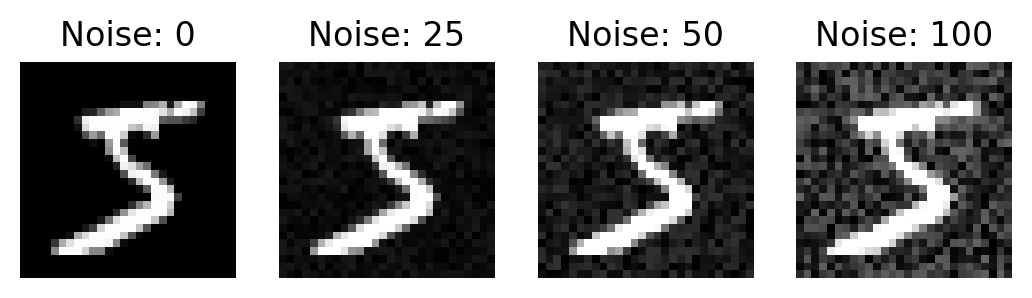

In [89]:
# prepare noise levels and the first image of 5 from MNIST
y_noise = [0, 25, 50, 100]
first_image = train_images[0]

fig, ax = plt.subplots(1, 4)

# Plot the first image from the MNIST data set with noise levels (0, 25, 50, 100)
for i in range(len(y_noise)):
  ax[i].set_title("Noise: "+str(y_noise[i]))
  ax[i].imshow(addNoiseToMNIST(y_noise[i],first_image), cmap = 'grey')
  ax[i].axis('off')

# Part 2
I will train a model without noise and inspect its performance under different level of noises by ploting accuraies against noise level

In [82]:
# load the MNIST dataset
mnist = keras.datasets.mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# normalising the pixel values in between 0 and 1
train_images_norm=train_images/255.0
test_images_norm=test_images/255.0

In [90]:
# Set up the layers
model_1 = keras.Sequential([
    keras.layers.Input(shape=(28,28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128,activation='relu'),
    keras.layers.Dense(10)
])

# Compile the model with parameters
model_1.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), optimizer=tf.keras.optimizers.SGD(learning_rate=0.5),
              metrics=['accuracy'])

# train the network using train_images and run the training for 15 epochs to allow the model to learn the patterns
model_1.fit(train_images_norm, train_labels, batch_size = 100, epochs=15)

Epoch 1/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8464 - loss: 0.4835
Epoch 2/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9627 - loss: 0.1247
Epoch 3/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9764 - loss: 0.0830
Epoch 4/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9809 - loss: 0.0648
Epoch 5/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9849 - loss: 0.0505
Epoch 6/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9873 - loss: 0.0427
Epoch 7/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9887 - loss: 0.0368
Epoch 8/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9930 - loss: 0.0267
Epoch 9/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9936 - loss: 0.0227
Epoch 10/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9954 - loss: 0.0183
Epoch 11/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9960 - loss: 0.0149
Epoch 12/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step

In [91]:
# Test the performance of the trained network by using test_images
test_loss, test_acc = model_1.evaluate(test_images_norm, test_labels, verbose=2)
print(f"Test accuracy: {test_acc*100}%")

313/313 - 1s - 3ms/step - accuracy: 0.9804 - loss: 0.0690
Test accuracy: 98.0400025844574%


In [53]:
def performance_under_noise(model, yNoise, data, labels):
  """
  to evaluate the accuracy of the model under different noise levels
  Args:
      model: trained model.
      yNoise: amount of noise to add.
      data: MNIST images.
      labels: MNIST labels.
  Returns:
      accuracy_result: accuracy (list) of the model under different noise levels.
  """
  accuracy_result = []

  for i in range(len(yNoise)):
    noisy_data = addNoiseToMNIST(yNoise[i], data.copy())
    noisy_data_norm = noisy_data/255.0
    test_loss, test_acc = model.evaluate(noisy_data_norm, labels, verbose=0)

    accuracy_result.append(test_acc)

  return accuracy_result

Text(0.5, 1.0, 'Model 1 performance under noise')

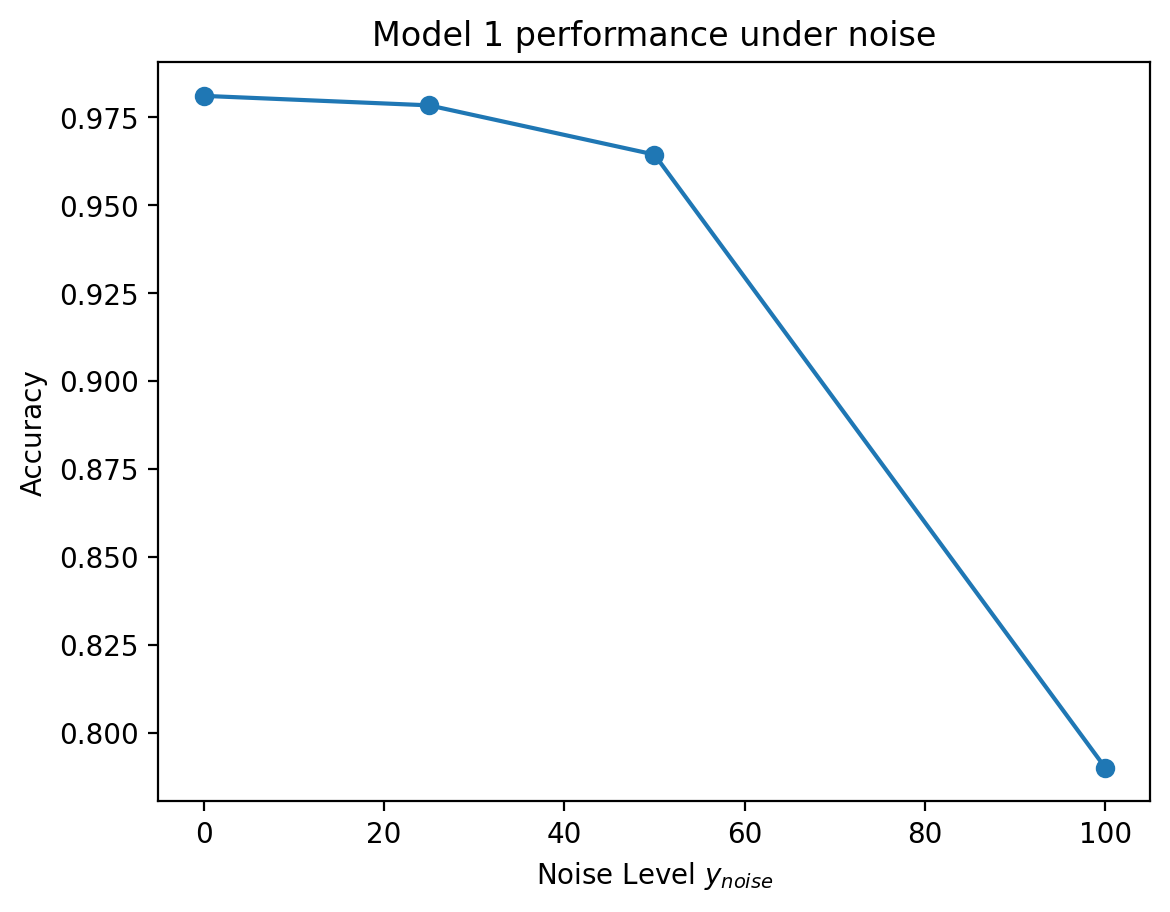

In [85]:
# load the MNIST dataset
mnist = keras.datasets.mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# prepare raw data
y_noise = [0, 25, 50, 100]

# to get the set of accuracies under y_noise
acc_model_1 = performance_under_noise(model_1, y_noise, test_images, test_labels)

# plot accuracy against noise level
fig, ax = plt.subplots()
ax.plot(y_noise, acc_model_1, marker = 'o')
ax.set_xlabel(r"Noise Level $y_{noise}$")
ax.set_ylabel("Accuracy")
ax.set_title("Model 1 performance under noise")


## Part 3
In this section, I will implement a function to train models under varying levels of training noise and record their accuracies. Subsequently, each model's robustness will be evaluated against a standard range of $y_{noise}$ levels. Finally, the results will be plotted to provide a direct visual comparison of their performance.

In [86]:
def TrainingModelwithNoise(noise_level, train_images, train_labels,test_images, test_labels):
  """
  To train a model with noise and evaluate its performance under different noise levels

  Args:
    noise_level: list of noise levels
    train_images: training images
    train_labels: training labels
    test_images: testing images
    test_labels: testing labels

  Returns:
    accuracy_results: list of accuracies under different noise levels
  """
  noise_train = addNoiseToMNIST(noise_level, train_images.copy())
  noise_train_norm = noise_train/255.0

  model = keras.Sequential([
    keras.layers.Input(shape=(28,28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128,activation='relu'),
    keras.layers.Dense(10)
])
  model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), optimizer=tf.keras.optimizers.SGD(learning_rate=0.5),
              metrics=['accuracy'])

  model.fit(noise_train_norm, train_labels, epochs= 15, batch_size = 100, verbose = 0)

  y_noise = [0, 25, 50, 100]

  accuracy_results = performance_under_noise(model, y_noise, test_images, test_labels)

  return accuracy_results

In [87]:
# define training noise levels
noise_levels = [0, 25, 50, 100]
y_noise = [0, 25, 50, 100]

# to store final results for plotting
final_results = {}

# run a loop to get the accuracies change at different y_noise for models with different training noises
for noise_level in noise_levels:
  accuracy_results = TrainingModelwithNoise(noise_level, train_images, train_labels, test_images, test_labels)
  final_results[noise_level] = accuracy_results

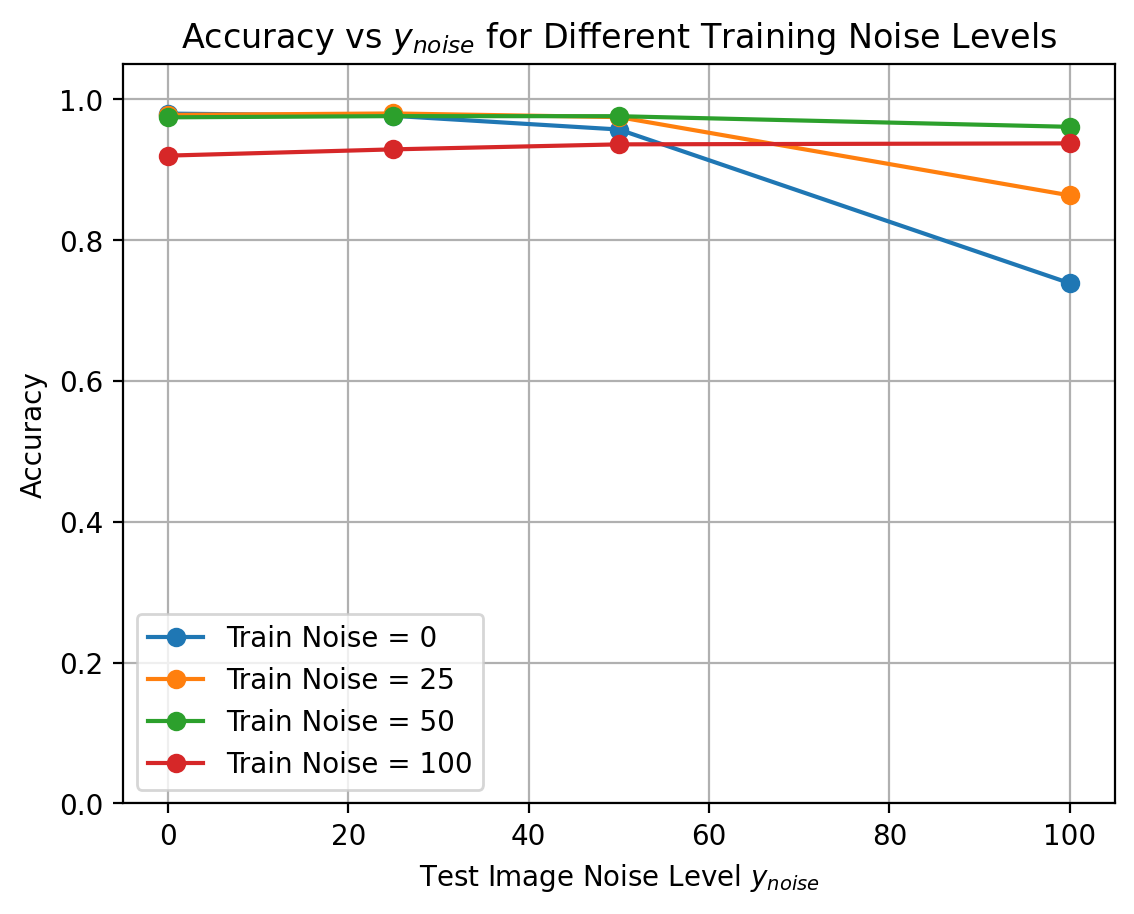

In [88]:
# Plot the final results, investigate the performance of models with different training noises.
for noise_level, accuracy_results in final_results.items():
  plt.plot(y_noise, accuracy_results, marker='o', label=f'Train Noise = {noise_level}')

plt.title(r'Accuracy vs $y_{noise}$ for Different Training Noise Levels')
plt.xlabel(r'Test Image Noise Level $y_{noise}$')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend(frameon = True)
plt.show()

## Comments on the result
According to the plot above, it is clear that the model with training noise = 50 (Green Line) shows the best performance across the entire $y_{noise}$ range, maintaining an accuracy of around 95%.

For both models with training noise 0 and 25 (Blue and Orange Lines), they are highly accurate at $y_{noise} = 0, 25$. However, their accuracies drop significantly at $y_{noise} = 50, 100$, showing poor robustness.

It is worth mentioning that the model with training noise = 100 (Red Line) shows increasing accuracies as noise level $y_{noise}$ increases, however, it sacrifices its performance at lower test noise levels.

Overall, the model with training noise = 50 has the best performance. At this level of training, the model retains its ability to recognise clean data while acquiring exceptional robustness against noise, achieving an optimal balance between performance and robustness.